# Symulacja ceny napoju energetycznego

Firma **EnergoMax** produkuje popularny napój energetyczny, który szybko zdobył popularność wśród młodych ludzi. Zespół analityczny zauważył, że cena napoju w ciągu roku **nie jest stała** – rośnie latem, gdy popyt jest największy, a spada zimą, gdy sprzedaż maleje.

Dodatkowo, przy bardzo wysokich cenach sprzedaż gwałtownie spada, a przy bardzo niskich napój rozchodzi się błyskawicznie, co powoduje problemy z dostawami. Chciano przewidzieć, jak zmieni się cena w czasie, aby **maksymalizować zysk i unikać nagłych spadków sprzedaży**.



Zespół stworzył model matematyczny, tzn. równanie, które spełnia optymalna cena napoju $y(t)$, gdzie $t$-czas, np. $y(0)$ oznacza cenę napoju dnia $0$ o godzinie $0:00$, $y(0.5)$ cenę dnia $0$ o godzinie $12:00$, $y(1)$ cenę napoju dnia $1$ o $0:00$ itd:

$$
y'(t) = a_0 + a_1 y + a_2 y^2 + a_3 \sin\Big(\frac{2\pi}{365} t\Big), \quad y(0) = a_4
$$

gdzie:  
- $y(t)$ – cena napoju w złotych w dniu \(t\),  
- $a_0$ – stały trend cenowy wynikający np. z inflacji i kosztów produkcji,  
- $a_1 y$ – efekt proporcjonalny do aktualnej ceny (np. spadek popytu przy wysokiej cenie),  
- $a_2 y^2$ – efekt nieliniowy (gwałtowne zmiany sprzedaży przy ekstremalnych cenach),  
- $a_3 \sin\Big(\frac{2\pi}{365} t\Big)$ – efekt sezonowy (wakacyjne wzrosty i zimowe spadki popytu),  
- $a_4$ – **cena początkowa napoju**.

Twoim zadaniem jest:  
1. Zaimplementować **metodę Eulera** dla tego równania.  
2. Rozwiązać równanie w określonym przedziale czasowym (tj. znaleźć funkcję $y(t)$).  
3. Narysować wykres ceny napoju w czasie i zobaczyć, jak zmienia się w zależności od wylosowanych liczb $a_0, a_1, a_2, a_3, a_4$.

Aby rozwiązać zadanie, przedstawimy czym jest metoda Eulera.

## Metoda Eulera dla równań różniczkowych

### Idea metody

Równanie różniczkowe zwyczajne (ODE) pierwszego rzędu ma postać:

$y'(t) = f(t, y(t)), \quad y(t_0) = y_0$

gdzie $y(t)$ jest funkcją, którą chcemy znaleźć, a $f(t, y(t))$ jest znaną funkcją określającą tempo zmian $y$ w zależności od $t$ i $y(t)$. Zauważmy, że nasze równanie mówi dokładnie tyle, że tempo zmian $y'(t)$ wynosi $f(t,y(t))$.

**Metoda Eulera** pozwala przybliżyć rozwiązanie tego równania krok po kroku, dzieląc przedział czasowy $[t_0, t_\text{end}]$ na małe kawałki o długości $h$ i obliczając wartość $y$ w kolejnych punktach.  

W metodzie Eulera dzielimy przedział czasowy $[t_0, t_\text{end}]$ na małe kawałki:

$t_0, t_1 = t_0 + h, t_2 = t_0 + 2h, \dots, t_n = t_0 + n h, \dots$

W każdym z tych punktów przybliżamy wartość funkcji $y(t)$:

- $y_0 = y(t_0)$ – wartość początkowa (dana w problemie),  
- $y_1 \approx y(t_1)$ – przybliżenie wartości $y$ w czasie $t_1$,  
- $y_2 \approx y(t_2)$ – przybliżenie wartości $y$ w czasie $t_2$,  
- i tak dalej aż do $y_n \approx y(t_n)$.

**Interpretacja:** $y_n$ to **przybliżona wartość funkcji $y(t)$ w punkcie $t_n$**, obliczona na podstawie wcześniejszych wartości i nachylenia funkcji $y$.  

1. Zaczynamy od wartości początkowej $y_0$ w czasie $t_0$.  
2. Przesuwamy się o mały krok $h$ w czasie, przybliżając nową wartość $y$ korzystając z nachylenia $f(t, y)$ w punkcie startowym:

$$y_{n+1} = y_n + h \cdot f(t_n, y_n)$$




Formuła rekurencyjna:

$$y_{n+1} = y_n + h \cdot f(t_n, y_n)$$

czyli nowa wartość $y_{n+1}$ powstaje poprzez dodanie do obecnej wartości $y_n$ zmiany w czasie $h$ określonej przez nachylenie $f(t_n, y_n)$.  

---

## Krok 1 - importujemy biblioteki

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Krok 2 - zdefiniujemy prostą funkcję testową

In [2]:
def f_test(t, y):
    return 0.5 * y

# Krok 3 - implementacja metody Eulera

Twoim zadaniem jest **zaimplementowanie metody Eulera** do przybliżonego rozwiązywania równań różniczkowych pierwszego rzędu:

$y'(t) = f(t, y(t)), \quad y(t_0) = y_0$

Poniżej znajdziesz szczegółową instrukcję, jak krok po kroku stworzyć funkcję `euler`.

---

### Krok 1: Przygotowanie funkcji
1. Nazwij funkcję `euler`.  
2. Funkcja powinna przyjmować następujące argumenty:
   - `f` – funkcja $f(t, y)$ definiująca równanie różniczkowe  
   - `y0` – wartość początkowa $y(t_0)$  
   - `t0` – początkowy czas $t_0$  
   - `t_end` – końcowy czas, do którego chcemy rozwiązać równanie  
   - `h` – krok czasowy, czyli długość małego kawałka, na który dzielimy przedział $[t_0, t_\text{end}]$

### Krok 2: Inicjalizacja list
- Utwórz listy `t_values` i `y_values`, w których będziesz przechowywać kolejne punkty:
  - `t_values[0] = t0`
  - `y_values[0] = y0`

### Krok 3: Pętla obliczeniowa
- Dopóki bieżący czas `t` jest mniejszy niż `t_end`, powtarzaj:
  1. Oblicz nowe $y_{n+1}$ według wzoru:
     
     $y_{n+1} = y_n + h \cdot f(t_n, y_n)$
  2. Dodaj nową wartość $y_{n+1}$ do listy `y_values`.  
  3. Zaktualizuj czas: `t = t + h` i dodaj do listy `t_values`.

### Krok 4: Zwracanie wyników
- Po zakończeniu pętli funkcja powinna zwrócić dwie listy: `t_values` i `y_values`, które będą zawierać odpowiednio punkty czasowe i przybliżone wartości $y_n$.

In [3]:
def euler(f, y0, t0, t_end, h):
    """
    Rozwiązuje równanie y'(t) = f(t, y(t)) metodą Eulera.

    Parametry:
    f      : funkcja f(t, y)
    y0     : wartość początkowa y(t0)
    t0     : początkowy czas
    t_end  : końcowy czas
    h      : krok czasowy

    Zwraca:
    t_values : lista punktów czasowych
    y_values : lista przybliżonych wartości y w tych punktach
    """
    # Krok 1: inicjalizacja list z pierwszymi punktami
    t_values = [t0]
    y_values = [y0]

    # Bieżące wartości czasu i y
    t = t0
    y = y0

    # Krok 2: pętla obliczeniowa
    while t < t_end:
        # obliczenie kolejnej wartości y
        y = y + h * f(t, y)
        # aktualizacja czasu
        t = t + h
        # zapisanie wyników
        t_values.append(t)
        y_values.append(y)

    # Krok 3: zwrócenie wyników
    return t_values, y_values


## Krok 4 - testowanie
- Przetestuj swoją funkcję na prostym równaniu testowym:

$y'(t) = 0.5 y, \quad y(0) = 1$

- Wykonaj obliczenia w przedziale $t \in [0, 2]$ z krokiem $h = 0.2$.  
- Narysuj wykres punktów $y_n$ połączonych linią, aby zobaczyć przybliżoną trajektorię rozwiązania.

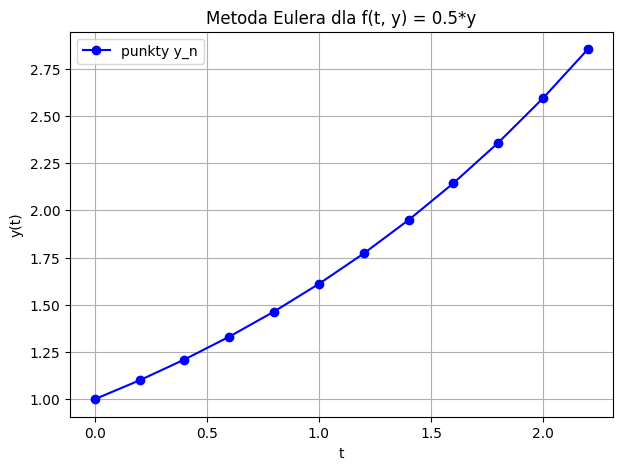

In [4]:
# Parametry
y0 = 1
t0 = 0
t_end = 2
h = 0.2

# Wywołanie metody Eulera
t_values, y_values = euler(f_test, y0, t0, t_end, h)

# Wykres punktów y_n
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(t_values, y_values, '-o', color='blue', markersize=6, label='punkty y_n')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title("Metoda Eulera dla f(t, y) = 0.5*y")
plt.grid(True)
plt.legend()
plt.show()

## Krok 5 - losujemy parametry dla naszego modelu sprzedaży energetyków

In [20]:
np.random.seed(359502) #Podaj swój numer indeksu

# Losujemy liczby w wybranym zakresie
a_0 = np.random.uniform(0,0.2)
a_1 = np.random.uniform(-0.00001,0.00001)
a_2 = np.random.uniform(-0.00001,0.00001)
a_3 = np.random.uniform(0, 0.5)
a_4 = np.random.uniform(4,6)  # cena początkowa

print("Wylosowane parametry:")
print(f"a_0 = {a_0:.3f}, a_1 = {a_1:.3f}, a_2 = {a_2:.3f}, a_3 = {a_3:.3f}, a_4 = {a_4:.3f}")

Wylosowane parametry:
a_0 = 0.199, a_1 = -0.000, a_2 = -0.000, a_3 = 0.224, a_4 = 5.710


## Krok 6 - definujemy funkcję z naszego modelu i podajemy cenę początkową

In [21]:
def f_price(t, y):
    """
    Funkcja f(t, y) dla równania ceny napoju:
    y'(t) = a0 + a1*y + a2*y^2 + a3*sin(2*pi/365 * t)
    """
    return a_0 + a_1*y + a_2*y**2 + a_3*np.sin(2*np.pi/365 * t)

y0_price = a_4

## Krok 7
W tej sekcji używamy **metody Eulera**, aby przewidzieć, jak zmieni się cena napoju energetycznego w ciągu roku.  

### Założenia modelu
Równanie opisujące dynamikę ceny napoju to:

$y'(t) = a_0 + a_1 y + a_2 y^2 + a_3 \sin\Big(\frac{2 \pi}{365} t\Big), \quad y(0) = a_4$

gdzie:
- $y(t)$ – cena napoju w dniu $t$,  
- $a_0$ – stały trend cenowy (np. inflacja i koszty produkcji),  
- $a_1 y$ – efekt proporcjonalny do aktualnej ceny (np. spadek popytu przy wysokiej cenie),  
- $a_2 y^2$ – efekt nieliniowy (gwałtowne zmiany przy ekstremalnych cenach),  
- $a_3 \sin(2\pi/365 \, t)$ – efekt sezonowy (wakacyjne wzrosty i zimowe spadki popytu),  
- $a_4$ – cena początkowa napoju.

Parametry $a_0, a_1, a_2, a_3, a_4$ zostały **wylosowane**.

---

### Zastosowanie metody Eulera
- Przedział czasowy $[0, 365]$ dni został podzielmy na małe kroki $h = 1$ (codziennie).  
- W każdym kroku obliczamy przybliżoną wartość $y_n \approx y(t_n)$ według wzoru:

$y_{n+1} = y_n + h \cdot f(t_n, y_n)$

- Lista $y_n$ zawiera wszystkie przybliżone wartości ceny w kolejnych dniach.

---

### Interpretacja wykresu
- **Punkty na wykresie** to wartości $y_n$ obliczone metodą Eulera.  
- **Linia łącząca punkty** pokazuje przybliżoną trajektorię zmiany ceny napoju w czasie.  

In [22]:
# ==============================
# 1. Parametry metody Eulera
# ==============================
t0 = 0        # początek czasu (dzień 0)
t_end = 365   # koniec czasu (rok)
h = 1         # krok czasowy (1 dzień)

# ==============================
# 2. Zastosowanie metody Eulera
# ==============================
t_values, y_values = euler(f_price, y0_price, t0, t_end, h)

## Krok 8 - wykres funkcji

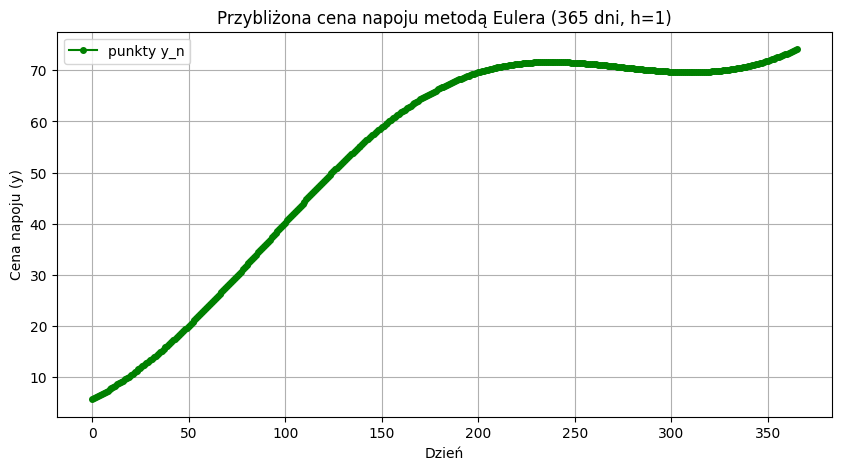

In [23]:
plt.figure(figsize=(10,5))
plt.plot(t_values, y_values, '-o', markersize=4, color='green', label='punkty y_n')
plt.xlabel('Dzień')
plt.ylabel('Cena napoju (y)')
plt.title("Przybliżona cena napoju metodą Eulera (365 dni, h=1)")
plt.grid(True)
plt.legend()
plt.show()

### Zadanie końcowe: cena napoju w dniu 180

Po wykonaniu symulacji metodą Eulera dla 365 dni:

1. Odczytaj przybliżoną wartość ceny napoju $y_n$ w **dniu 180**.  
   - W naszych listach `t_values` i `y_values` indeks odpowiada kolejnym dniom, czyli `y_values[180]` to przybliżona cena w dniu 180.  
2. Wypisz tę wartość na ekranie używając funkcji `print`, np.:

In [24]:
print("Cena napoju w dniu 180:", y_values[180])

Cena napoju w dniu 180: 66.45612929301367


## Przetestuj zanim oddasz finalną wersję pracy!

Odpowiedzi dla poszczególnych indeksów.
1. 111111 $y(180)=32.10732939977914$
2. 222222 $y(180)=35.32354644099457$
3. 333333 $y(180)=73.94093511247702$
4. 444444 $y(180)=71.48019698144512$
5. 555555 $y(180)=44.6301196250986$